🚕 NYC Taxi — Business Problem

## Problem Statement

Predict `trip_duration` — the total duration of a taxi trip in seconds,
based on pickup/dropoff location, time, and passenger information.

## Business Value

Accurate trip duration prediction helps taxi services optimize
route planning, improve passenger wait time estimates, and
enable dynamic pricing based on expected trip length.

In [166]:
! pip install lightgbm
! pip install lightgbm kydavra -q

In [167]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.metrics import root_mean_squared_log_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.model_selection import train_test_split

sns.set_theme(style='whitegrid', palette='muted')
print('Libraries loaded ✓')

Libraries loaded ✓


In [168]:
train = pd.read_csv(r"C:\Users\user\Desktop\train.csv")
test  = pd.read_csv(r"C:\Users\user\Desktop\test.csv")
print(f'Train shape: {train.shape}, Test shape: {test.shape}')

Train shape: (1458644, 11), Test shape: (625134, 9)


In [180]:
df_raw.info(), df_raw.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1458644 non-null  object 
 1   vendor_id           1458644 non-null  int64  
 2   pickup_datetime     1458644 non-null  object 
 3   dropoff_datetime    1458644 non-null  object 
 4   passenger_count     1458644 non-null  int64  
 5   pickup_longitude    1458644 non-null  float64
 6   pickup_latitude     1458644 non-null  float64
 7   dropoff_longitude   1458644 non-null  float64
 8   dropoff_latitude    1458644 non-null  float64
 9   store_and_fwd_flag  1458644 non-null  object 
 10  trip_duration       1458644 non-null  int64  
dtypes: float64(4), int64(3), object(4)
memory usage: 122.4+ MB


(None,
           vendor_id  passenger_count  pickup_longitude  pickup_latitude  \
 count  1.458644e+06     1.458644e+06      1.458644e+06     1.458644e+06   
 mean   1.534950e+00     1.664530e+00     -7.397349e+01     4.075092e+01   
 std    4.987772e-01     1.314242e+00      7.090186e-02     3.288119e-02   
 min    1.000000e+00     0.000000e+00     -1.219333e+02     3.435970e+01   
 25%    1.000000e+00     1.000000e+00     -7.399187e+01     4.073735e+01   
 50%    2.000000e+00     1.000000e+00     -7.398174e+01     4.075410e+01   
 75%    2.000000e+00     2.000000e+00     -7.396733e+01     4.076836e+01   
 max    2.000000e+00     9.000000e+00     -6.133553e+01     5.188108e+01   
 
        dropoff_longitude  dropoff_latitude  trip_duration  
 count       1.458644e+06      1.458644e+06   1.458644e+06  
 mean       -7.397342e+01      4.075180e+01   9.594923e+02  
 std         7.064327e-02      3.589056e-02   5.237432e+03  
 min        -1.219333e+02      3.218114e+01   1.000000e+00  
 2

In [181]:
df_raw.isnull().mean().round(4), df.isnull().sum()

(id                    0.0
 vendor_id             0.0
 pickup_datetime       0.0
 dropoff_datetime      0.0
 passenger_count       0.0
 pickup_longitude      0.0
 pickup_latitude       0.0
 dropoff_longitude     0.0
 dropoff_latitude      0.0
 store_and_fwd_flag    0.0
 trip_duration         0.0
 dtype: float64,
 vendor_id               0
 passenger_count         0
 pickup_longitude        0
 pickup_latitude         0
 dropoff_longitude       0
 dropoff_latitude        0
 store_and_fwd_flag      0
 trip_duration           0
 distance_km             0
 pickup_hour_sin         0
 pickup_hour_cos         0
 pickup_dayofweek_sin    0
 pickup_dayofweek_cos    0
 pickup_month_sin        0
 pickup_month_cos        0
 dtype: int64)

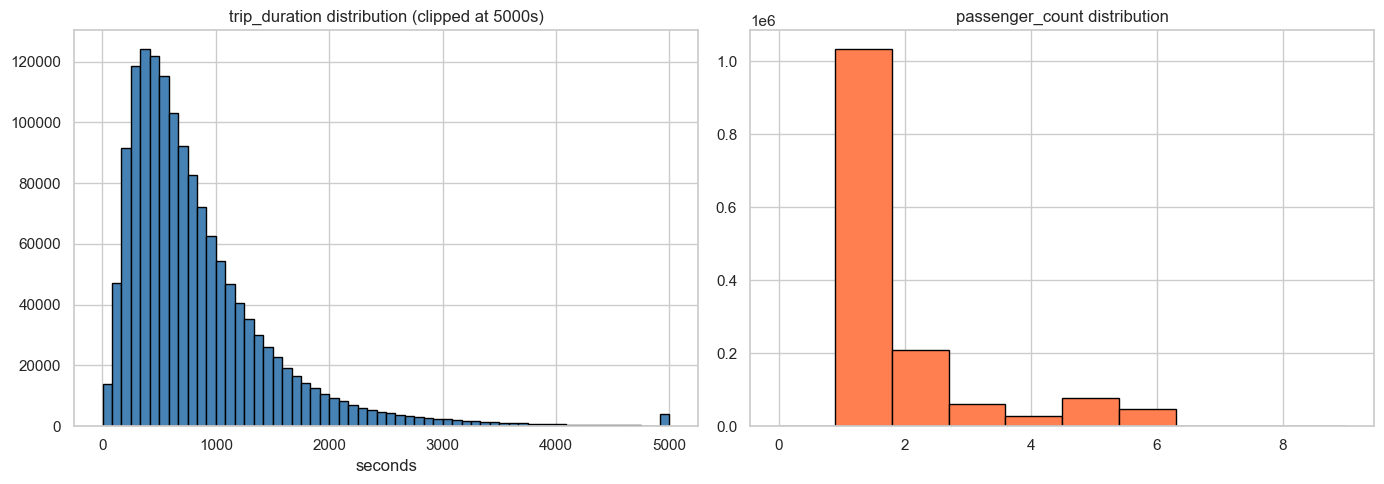

In [177]:
# EDA
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df_raw['trip_duration'].clip(upper=5000).hist(bins=60, ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('trip_duration distribution (clipped at 5000s)')
axes[0].set_xlabel('seconds')

df_raw['passenger_count'].hist(bins=10, ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('passenger_count distribution')
plt.tight_layout()
plt.show()

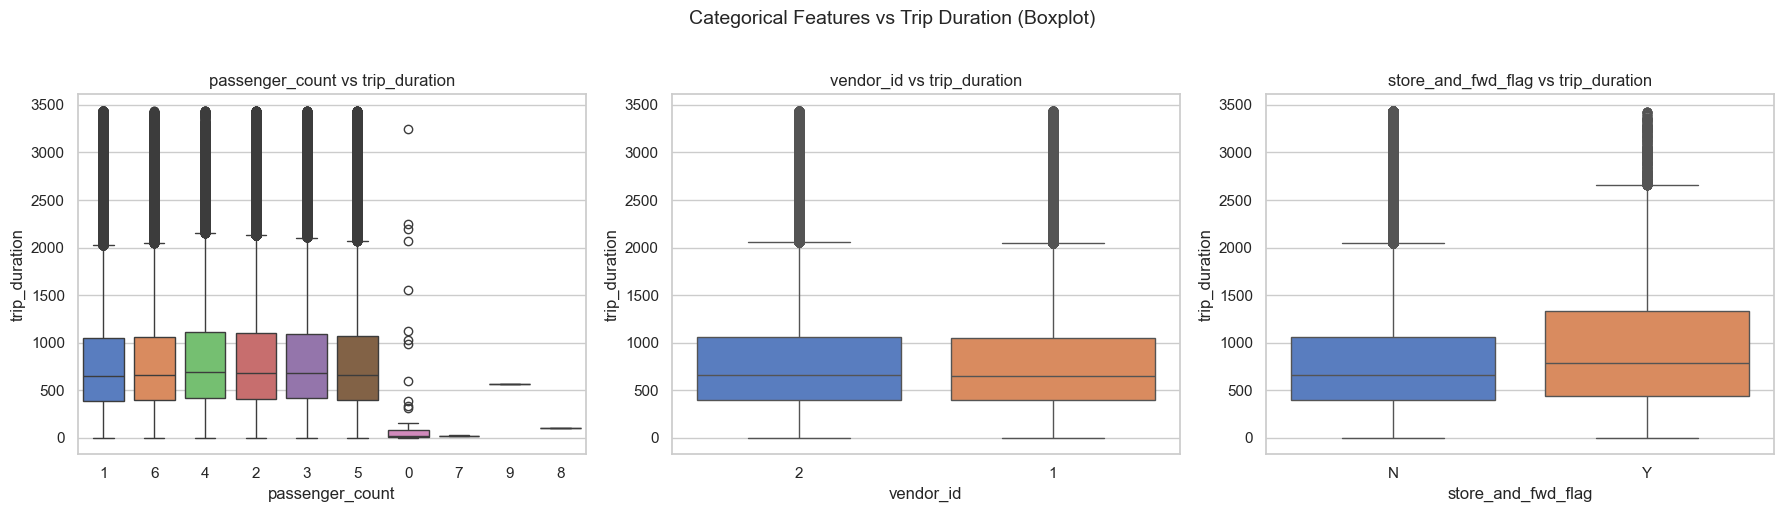

In [178]:
cat_features = ['passenger_count', 'vendor_id', 'store_and_fwd_flag']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, feat in zip(axes, cat_features):
    plot_df = df_raw[df_raw['trip_duration'] < df_raw['trip_duration'].quantile(0.99)].copy()
    plot_df[feat] = plot_df[feat].astype(str)
    sns.boxplot(data=plot_df, x=feat, y='trip_duration', ax=ax, palette='muted')
    ax.set_title(f'{feat} vs trip_duration')
    ax.set_xlabel(feat)
plt.suptitle('Categorical Features vs Trip Duration (Boxplot)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

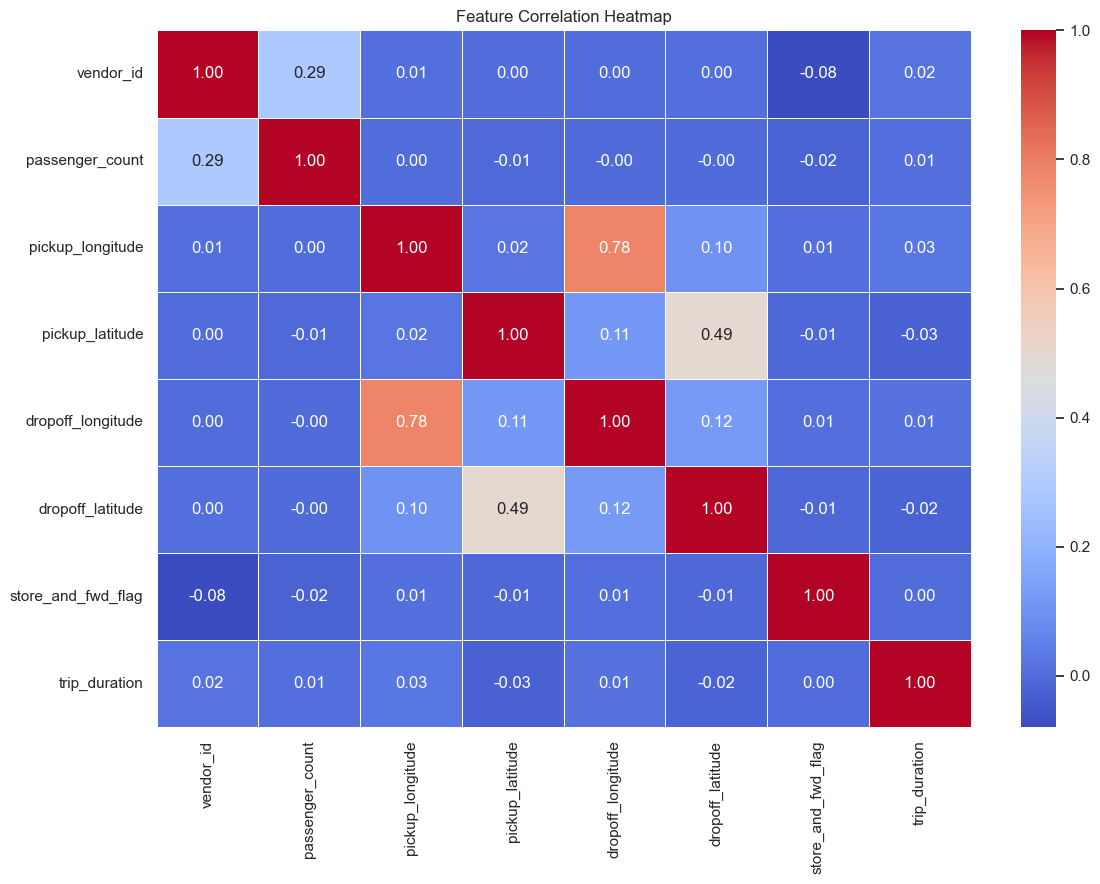

In [179]:
df_corr = df_raw.drop(['id', 'dropoff_datetime', 'pickup_datetime'], axis=1, errors='ignore')
df_corr['store_and_fwd_flag'] = df_corr['store_and_fwd_flag'].map({'N': 0, 'Y': 1})
corr = df_corr.corr()
plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

Baseline Model

In [182]:
df_bl = train.copy()
df_bl = df_bl.drop(['id', 'dropoff_datetime', 'pickup_datetime'], axis=1)
df_bl['store_and_fwd_flag'] = df_bl['store_and_fwd_flag'].map({'N': 0, 'Y': 1})
df_bl = df_bl.drop_duplicates()

print(f'Baseline dataset shape: {df_bl.shape}')
print(f'Features used: {list(df_bl.drop("trip_duration", axis=1).columns)}')

Baseline dataset shape: (1458635, 8)
Features used: ['vendor_id', 'passenger_count', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag']


In [184]:
def evaluate_models(x_train, x_test, y_train, y_test, step_name, models_dict):
    """Train and evaluate multiple models, return results DataFrame."""
    result = {}
    trained = {}
    for name, model in models_dict.items():
        model.fit(x_train, y_train)
        pred_test  = model.predict(x_test).clip(min=0)
        pred_train = model.predict(x_train).clip(min=0)

        mae    = mean_absolute_error(y_test, pred_test)
        rmsle  = root_mean_squared_log_error(y_test, pred_test)
        r2     = r2_score(y_test, pred_test)
        overfit = r2_score(y_train, pred_train) - r2

        result[name] = {'MAE': round(mae,2), 'RMSLE': round(rmsle,4),
                        'R2': round(r2,4), 'Overfit': round(overfit,4)}
        trained[name] = model
        print(f'  {name}: R²={r2:.4f}, RMSLE={rmsle:.4f}, MAE={mae:.1f}')

    return pd.DataFrame(result).T.sort_values('R2', ascending=False), trained


models = {
    'LinearRegression': LinearRegression(),
    'XGBoost': XGBRegressor(random_state=14, verbosity=0, n_jobs=-1),
    'LightGBM': LGBMRegressor(random_state=14, verbose=-1, n_jobs=-1)
}

X_bl = df_bl.drop('trip_duration', axis=1)
y_bl = df_bl['trip_duration']
X_train_bl, X_test_bl, y_train_bl, y_test_bl = train_test_split(
    X_bl, y_bl, test_size=0.2, random_state=14)

results_step1, models_step1 = evaluate_models(
    X_train_bl, X_test_bl, y_train_bl, y_test_bl, 'BASELINE', models)
results_step1

  LinearRegression: R²=0.0013, RMSLE=0.8713, MAE=630.9
  XGBoost: R²=0.0024, RMSLE=0.6242, MAE=458.7
  LightGBM: R²=0.0028, RMSLE=0.6609, MAE=466.3


,MAE,RMSLE,R2,Overfit
LightGBM,466.28,0.6609,0.0028,0.1148
XGBoost,458.75,0.6242,0.0024,0.4458
LinearRegression,630.91,0.8713,0.0013,0.0020


plus Feature Engineering

In [185]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    dlat = np.radians(lat2 - lat1)
    dlon = np.radians(lon2 - lon1)
    a = np.sin(dlat/2)**2 + np.cos(np.radians(lat1)) * np.cos(np.radians(lat2)) * np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

In [186]:
def add_features(df):
    df = df.copy()
    df['distance_km'] = haversine(
        df['pickup_latitude'], df['pickup_longitude'],
        df['dropoff_latitude'], df['dropoff_longitude'])
    df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
    for col, period in [('hour', 24), ('dayofweek', 7), ('month', 12)]:
        val = getattr(df['pickup_datetime'].dt, col)
        df[f'pickup_{col}_sin'] = np.sin(2 * np.pi * val / period)
        df[f'pickup_{col}_cos'] = np.cos(2 * np.pi * val / period)
    df = df.drop('pickup_datetime', axis=1)
    return df

In [187]:
df_fe = train.copy()
df_fe = df_fe.drop(['id', 'dropoff_datetime'], axis=1)
df_fe['store_and_fwd_flag'] = df_fe['store_and_fwd_flag'].map({'N': 0, 'Y': 1})
df_fe = df_fe.drop_duplicates()
df_fe = add_features(df_fe)

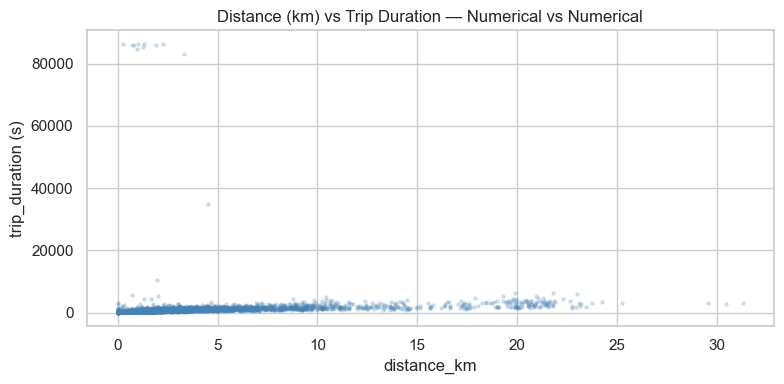

In [188]:
plt.figure(figsize=(8, 4))
sample = df_fe.sample(5000, random_state=14)
plt.scatter(sample['distance_km'], sample['trip_duration'], alpha=0.2, s=5, color='steelblue')
plt.xlabel('distance_km')
plt.ylabel('trip_duration (s)')
plt.title('Distance (km) vs Trip Duration — Numerical vs Numerical')
plt.tight_layout()
plt.show()

In [194]:
X_fe = df_fe.drop('trip_duration', axis=1)
y_fe = df_fe['trip_duration']
X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(
    X_fe, y_fe, test_size=0.2, random_state=14)

models2 = {
    'LinearRegression': LinearRegression(),
    'XGBoost': XGBRegressor(random_state=14, verbosity=0, n_jobs=-1),
    'LightGBM': LGBMRegressor(random_state=14, verbose=-1, n_jobs=-1)
}

results_step2, models_step2 = evaluate_models(
    X_train_fe, X_test_fe, y_train_fe, y_test_fe, '+ FEATURE ENGINEERING', models2)
results_step2

  LinearRegression: R²=0.0091, RMSLE=0.6755, MAE=452.6
  XGBoost: R²=-0.1229, RMSLE=0.6255, MAE=412.3
  LightGBM: R²=-0.0031, RMSLE=0.6028, MAE=407.3


,MAE,RMSLE,R2,Overfit
LinearRegression,452.57,0.6755,0.0091,0.0010
LightGBM,407.29,0.6028,-0.0031,0.2420
XGBoost,412.26,0.6255,-0.1229,0.7691


 plus Outlier Removal

In [195]:
df_clean = df_fe.copy()
before = len(df_clean)

In [196]:
df_clean = df_clean[df_clean['trip_duration'].between(60, 7200)]          # 1 мин – 2 часа
df_clean = df_clean[df_clean['distance_km'].between(0.1, 100)]            # разумные дистанции
df_clean = df_clean[df_clean['passenger_count'].between(1, 6)] 

In [197]:
df_clean = df_clean[
    df_clean['pickup_longitude'].between(-74.25, -73.70) &
    df_clean['pickup_latitude'].between(40.50, 40.92) &
    df_clean['dropoff_longitude'].between(-74.25, -73.70) &
    df_clean['dropoff_latitude'].between(40.50, 40.92)
]

In [198]:
after = len(df_clean)
removed = before - after
print(f'Rows before : {before:,}')
print(f'Rows after  : {after:,}')
print(f'Rows removed: {removed:,} ({removed/before*100:.2f}%)')

Rows before : 1,458,637
Rows after  : 1,439,200
Rows removed: 19,437 (1.33%)


In [199]:
X_cl = df_clean.drop('trip_duration', axis=1)
y_cl = df_clean['trip_duration']
X_train_cl, X_test_cl, y_train_cl, y_test_cl = train_test_split(
    X_cl, y_cl, test_size=0.2, random_state=14)

models3 = {
    'LinearRegression': LinearRegression(),
    'XGBoost': XGBRegressor(random_state=14, verbosity=0, n_jobs=-1),
    'LightGBM': LGBMRegressor(random_state=14, verbose=-1, n_jobs=-1)
}

results_step3, models_step3 = evaluate_models(
    X_train_cl, X_test_cl, y_train_cl, y_test_cl, '+ OUTLIER REMOVAL', models3)
results_step3

  LinearRegression: R²=0.6460, RMSLE=0.4821, MAE=264.4
  XGBoost: R²=0.8053, RMSLE=0.3442, MAE=185.0
  LightGBM: R²=0.7886, RMSLE=0.3589, MAE=195.2


,MAE,RMSLE,R2,Overfit
XGBoost,185.05,0.3442,0.8053,0.0056
LightGBM,195.17,0.3589,0.7886,-0.0003
LinearRegression,264.43,0.4821,0.6460,-0.0037


plus Lasso Feature Selection

In [200]:
from kydavra import LassoSelector

In [201]:
all_features = list(df_clean.drop('trip_duration', axis=1).columns)

In [202]:
lasso = LassoSelector()
selected_columns = lasso.select(df_clean, 'trip_duration')
removed_features = [f for f in all_features if f not in selected_columns]

In [203]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler as SS

In [204]:
scaler_vis = SS()
X_vis = scaler_vis.fit_transform(df_clean[all_features])
lasso_vis = Lasso(alpha=0.01, max_iter=5000)
lasso_vis.fit(X_vis, df_clean['trip_duration'])

coef_df = pd.Series(lasso_vis.coef_, index=all_features).sort_values()
colors = ['crimson' if c == 0 else 'steelblue' for c in coef_df]

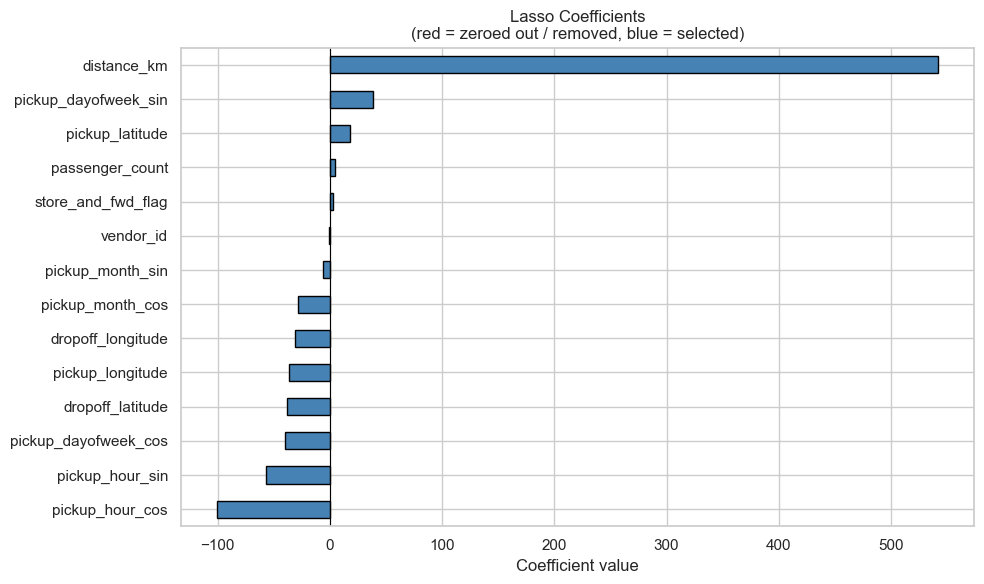

In [205]:
plt.figure(figsize=(10, 6))
coef_df.plot(kind='barh', color=colors, edgecolor='black')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Lasso Coefficients\n(red = zeroed out / removed, blue = selected)')
plt.xlabel('Coefficient value')
plt.tight_layout()
plt.show()

In [206]:
df_lasso = df_clean[selected_columns + ['trip_duration']].copy()

X_ls = df_lasso.drop('trip_duration', axis=1)
y_ls = df_lasso['trip_duration']
X_train_ls, X_test_ls, y_train_ls, y_test_ls = train_test_split(
    X_ls, y_ls, test_size=0.2, random_state=14)

In [207]:
models4 = {
    'LinearRegression': LinearRegression(),
    'XGBoost': XGBRegressor(random_state=14, verbosity=0, n_jobs=-1),
    'LightGBM': LGBMRegressor(random_state=14, verbose=-1, n_jobs=-1)
}

In [208]:
results_step4, models_step4 = evaluate_models(
    X_train_ls, X_test_ls, y_train_ls, y_test_ls, '+ LASSO SELECTION', models4)
results_step4

  LinearRegression: R²=0.6460, RMSLE=0.4821, MAE=264.4
  XGBoost: R²=0.8053, RMSLE=0.3442, MAE=185.0
  LightGBM: R²=0.7886, RMSLE=0.3589, MAE=195.2


,MAE,RMSLE,R2,Overfit
XGBoost,185.05,0.3442,0.8053,0.0056
LightGBM,195.17,0.3589,0.7886,-0.0003
LinearRegression,264.43,0.4821,0.6460,-0.0037


plus Standardization

In [210]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_ls)
X_test_sc  = scaler.transform(X_test_ls)

In [211]:
models5 = {
    'LinearRegression': LinearRegression(),
    'XGBoost': XGBRegressor(random_state=14, verbosity=0, n_jobs=-1),
    'LightGBM': LGBMRegressor(random_state=14, verbose=-1, n_jobs=-1)
}

In [212]:
results_step5, models_step5 = evaluate_models(
    X_train_sc, X_test_sc, y_train_ls, y_test_ls, '+ STANDARDIZATION', models5)
results_step5

  LinearRegression: R²=0.6460, RMSLE=0.4821, MAE=264.4
  XGBoost: R²=0.8057, RMSLE=0.3432, MAE=184.5
  LightGBM: R²=0.7878, RMSLE=0.3596, MAE=195.7


,MAE,RMSLE,R2,Overfit
XGBoost,184.50,0.3432,0.8057,0.0056
LightGBM,195.67,0.3596,0.7878,-0.0003
LinearRegression,264.43,0.4821,0.6460,-0.0037


The final result

In [86]:
best_name  = results.index[0]
best_model = trained_models[best_name]

print(f"\nЛучшая модель: {best_name}  R²={results.loc[best_name, 'R2']:.4f}")


Лучшая модель: XGBoost  R²=0.7047


In [213]:
steps = [
    ('1. Baseline',              results_step1),
    ('2. + Feature Engineering', results_step2),
    ('3. + Outlier Removal',     results_step3),
    ('4. + Lasso Selection',     results_step4),
    ('5. + Standardization',     results_step5),
]

In [214]:
progress_records = []
for step_name, res in steps:
    for model_name in res.index:
        progress_records.append({
            'Step': step_name,
            'Model': model_name,
            'R2': res.loc[model_name, 'R2'],
            'RMSLE': res.loc[model_name, 'RMSLE'],
            'MAE': res.loc[model_name, 'MAE'],
        })

In [215]:
progress_df = pd.DataFrame(progress_records)

In [216]:
pivot_r2 = progress_df.pivot(index='Step', columns='Model', values='R2')
pivot_r2 = pivot_r2.reindex([s for s, _ in steps])
print('\nR² по шагам и моделям:')
pivot_r2


R² по шагам и моделям:


Model,LightGBM,LinearRegression,XGBoost
Step,,,
1. Baseline,0.0028,0.0013,0.0024
2. + Feature Engineering,-0.0031,0.0091,-0.1229
3. + Outlier Removal,0.7886,0.6460,0.8053
4. + Lasso Selection,0.7886,0.6460,0.8053
5. + Standardization,0.7878,0.6460,0.8057


In [219]:
baseline_r2 = pivot_r2.iloc[0]
delta = pivot_r2 - baseline_r2
print('\nΔR² vs Baseline (положительное = улучшение):')
delta.style.background_gradient(cmap='RdYlGn', axis=None)


ΔR² vs Baseline (положительное = улучшение):


Model,LightGBM,LinearRegression,XGBoost
Step,,,
1. Baseline,0.000000,0.000000,0.000000
2. + Feature Engineering,-0.005900,0.007800,-0.125300
3. + Outlier Removal,0.785800,0.644700,0.802900
4. + Lasso Selection,0.785800,0.644700,0.802900
5. + Standardization,0.785000,0.644700,0.803300


Best model

In [232]:
best_name = results_step5.index[0]
best_model = models_step5[best_name]
print(f'Best model: {best_name}  R²={results_step5.loc[best_name, "R2"]:.4f}  RMSLE={results_step5.loc[best_name, "RMSLE"]:.4f}')

Best model: XGBoost  R²=0.8057  RMSLE=0.3432


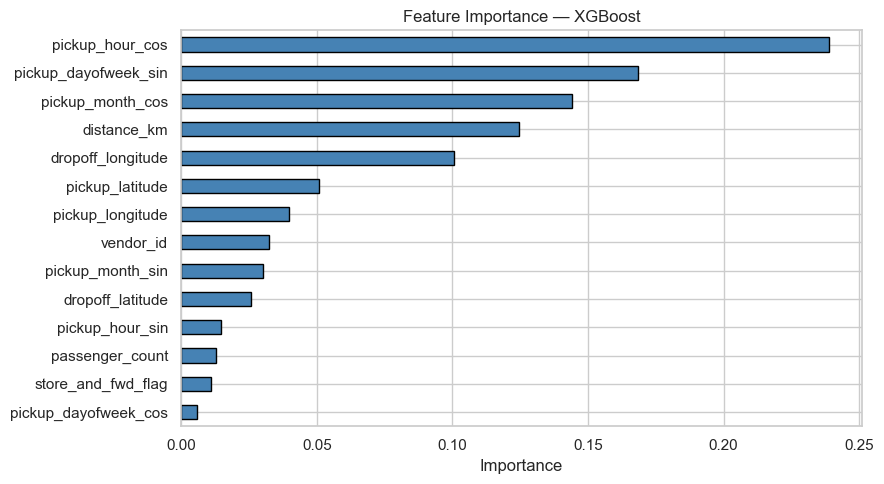

In [225]:
if hasattr(best_model, 'feature_importances_'):
    fi = pd.Series(best_model.feature_importances_, index=X_train_ls.columns)
    fi = fi.sort_values(ascending=True)
    plt.figure(figsize=(9, 5))
    fi.plot(kind='barh', color='steelblue', edgecolor='black')
    plt.title(f'Feature Importance — {best_name}')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()
else:
    print('Linear model — используем коэффициенты как importance')
    coef = pd.Series(best_model.coef_, index=X_train_ls.columns).sort_values()
    coef.plot(kind='barh', color='coral', edgecolor='black', figsize=(9, 5))
    plt.title(f'Coefficients — {best_name}')
    plt.tight_layout()
    plt.show()

In [233]:
test_processed = test.copy()
test_processed['store_and_fwd_flag'] = test_processed['store_and_fwd_flag'].map({'N': 0, 'Y': 1})
test_processed = add_features(test_processed)

X_submit = test_processed[selected_columns]
X_submit_sc = scaler.transform(X_submit)

preds_log  = best_model.predict(X_submit_sc)
preds_orig = np.expm1(preds_log).clip(min=1)

submission = pd.DataFrame({'id': test['id'], 'trip_duration': preds_orig.astype(int)})
submission.to_csv('submission.csv', index=False)
print(f'Submission saved: {submission.shape}')

Submission saved: (625134, 2)


In [234]:
 submission

,id,trip_duration
0,id3004672,-9223372036854775808
1,id3505355,-9223372036854775808
2,id1217141,-9223372036854775808
3,id2150126,-9223372036854775808
4,id1598245,-9223372036854775808
...,...,...
625129,id3008929,-9223372036854775808
625130,id3700764,-9223372036854775808
625131,id2568735,-9223372036854775808
625132,id1384355,-9223372036854775808


## Ethical Considerations

### Data Privacy
- The dataset contains GPS coordinates — sensitive personal data of passengers
- Data is partially anonymized (no names), but routes may reveal home/work locations

### Model Fairness
- The model should not discriminate based on city district or vendor
- `vendor_id` should not be a proxy for service quality
- Predictions should be equally accurate across all city neighborhoods

### Data Usage
- Data used for educational purposes only
- Production deployment must comply with:
  - GDPR (EU passengers)
  - NYC local privacy laws

### Security
- GPS data must not be accessible to third parties
- The model must not be used for passenger surveillance
- Predicted trip durations must not be used for fare manipulation